# SDS210 - Individual Project: ZueriWieNeu - Exploring

<div class="page-subtitle">
Raphael Knecht | SDS210 Programming with Spatial Data | FS 2026 | 22.05.2026
</div>

In [3]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data"

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

reports_fp = DATA_DIR / "stzh.zwn_meldungen_p.csv"
quartier_fp = DATA_DIR / "zh_neighbourhoods.gpkg"

print("Project folder:", PROJECT_DIR)
print("Reports file exists:", reports_fp.exists())
print("Quartier file exists:", quartier_fp.exists())

Project folder: /Users/raphi.knecht/Documents/Studium/07_FS2026/sds210-project
Reports file exists: True
Quartier file exists: True


In [ ]:
reports = pd.read_csv(reports_fp)

print("Rows and columns:", reports.shape)
display(reports.head())

Rows and columns: (73306, 19)


,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14T15:16:15,2013-04-04T07:25:05,2013-04-12T07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14T15:17:57,2013-03-26T14:05:05,2013-04-12T08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15T09:14:16,2013-03-15T09:55:05,2013-04-12T08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15T09:17:15,2013-03-20T10:05:05,2013-04-12T08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15T10:36:53,2013-04-22T18:25:05,2013-04-23T13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)


: 

In [ ]:
display(reports.columns.to_frame(index=False, name="column_name"))

,column_name
0,objectid
1,service_request_id
2,requested_datetime
3,agency_sent_datetime
4,updated_datetime
5,e
6,n
7,service_code
8,service_name
9,status


: 

In [ ]:
display(reports.dtypes.to_frame("dtype"))

,dtype
objectid,int64
service_request_id,int64
requested_datetime,str
agency_sent_datetime,str
updated_datetime,str
e,int64
n,int64
service_code,str
service_name,str
status,str


: 

In [ ]:
missing = reports.isna().sum().sort_values(ascending=False)
display(missing.to_frame("missing_values"))

,missing_values
media_url,22836
service_notice,853
agency_sent_datetime,833
title,2
detail,2
objectid,0
service_request_id,0
requested_datetime,0
updated_datetime,0
e,0


: 

In [ ]:
display(reports.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
objectid,73306.0,NaN,NaN,NaN,36656.246105,21163.679203,1.0,18327.25,36656.5,54983.75,73312.0
service_request_id,73306.0,NaN,NaN,NaN,40661.046013,23784.524405,1.0,19897.25,40350.5,61530.75,81896.0
requested_datetime,73306,73291,2013-08-22T11:10:08,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agency_sent_datetime,72473,61093,2023-07-17T08:27:04,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
updated_datetime,73306,72083,2013-04-19T16:30:07,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
e,73306.0,NaN,NaN,NaN,2682372.715385,1819.397027,2677064.0,2681333.0,2682291.0,2683475.0,2689602.0
n,73306.0,NaN,NaN,NaN,1248374.828513,2191.609237,1241838.0,1247040.25,1248008.0,1249786.0,1254299.0
service_code,73306,10,Abfall/Sammelstelle,27653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service_name,73306,10,Abfall/Sammelstelle,27653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,73306,6,fixed - council,64047,NaN,NaN,NaN,NaN,NaN,NaN,NaN


: 

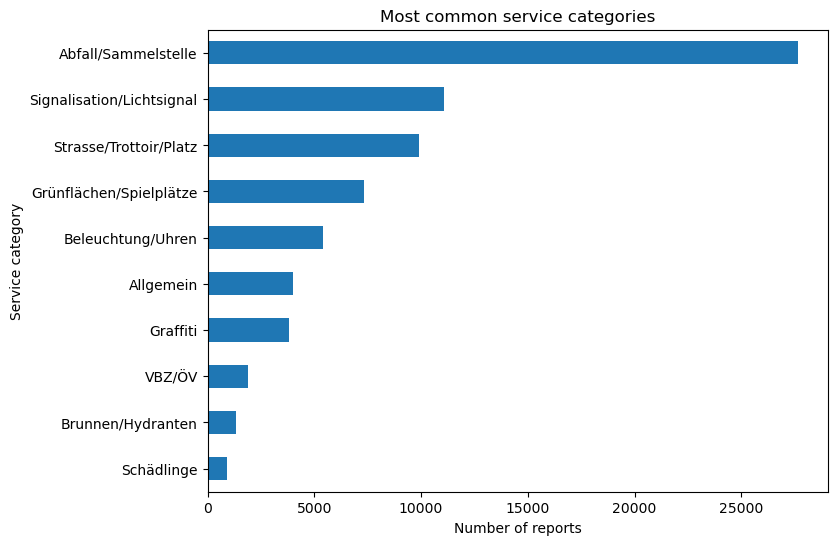

: 

In [ ]:
reports["service_name"].value_counts().head(15).plot(
    kind="barh",
    figsize=(8, 6),
    title="Most common service categories",
)
plt.xlabel("Number of reports")
plt.ylabel("Service category")
plt.gca().invert_yaxis()
plt.show()

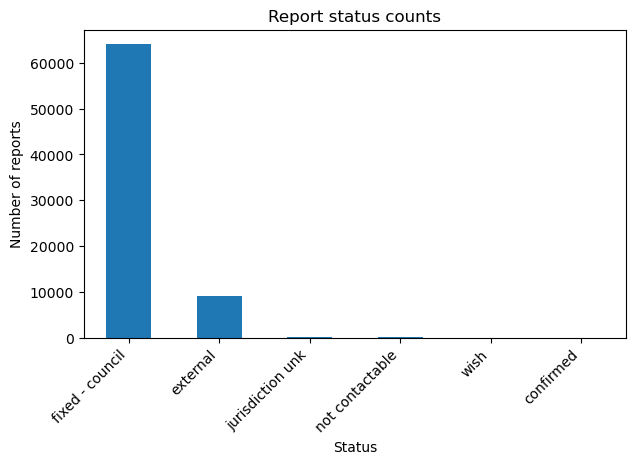

: 

In [ ]:
reports["status"].value_counts().plot(
    kind="bar",
    figsize=(7, 4),
    title="Report status counts",
)
plt.xlabel("Status")
plt.ylabel("Number of reports")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
reports["e"] = pd.to_numeric(reports["e"], errors="coerce")
reports["n"] = pd.to_numeric(reports["n"], errors="coerce")

print("Missing e coordinates:", reports["e"].isna().sum())
print("Missing n coordinates:", reports["n"].isna().sum())
display(reports[["e", "n"]].describe())

Missing e coordinates: 0
Missing n coordinates: 0


,e,n
count,7.330600e+04,7.330600e+04
mean,2.682373e+06,1.248375e+06
std,1.819397e+03,2.191609e+03
min,2.677064e+06,1.241838e+06
25%,2.681333e+06,1.247040e+06
50%,2.682291e+06,1.248008e+06
75%,2.683475e+06,1.249786e+06
max,2.689602e+06,1.254299e+06


: 

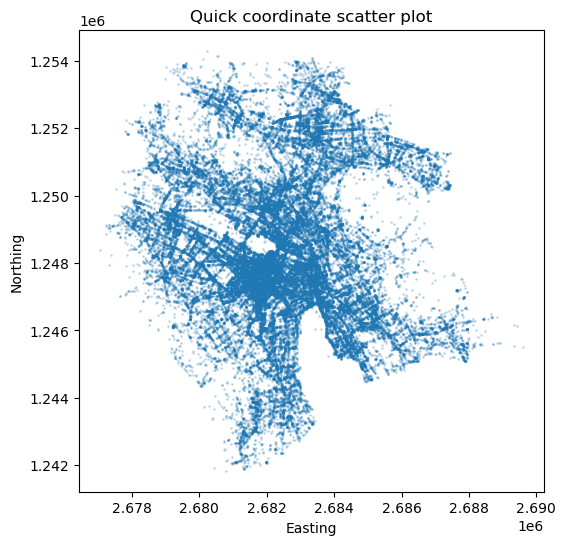

: 

In [ ]:
reports.plot.scatter(
    x="e",
    y="n",
    figsize=(6, 6),
    s=1,
    alpha=0.2,
    title="Quick coordinate scatter plot",
)
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()

In [ ]:
layers = gpd.list_layers(quartier_fp)
display(layers)

,name,geometry_type
0,stzh.adm_statistische_quartiere_b_p,Unknown
1,stzh.adm_statistische_quartiere_v,Unknown
2,stzh.adm_statistische_quartiere_map,Unknown


: 

In [ ]:
quartiere = gpd.read_file(quartier_fp, layer="stzh.adm_statistische_quartiere_v")

print("Rows and columns:", quartiere.shape)
print("CRS:", quartiere.crs)
display(quartiere.head())

Rows and columns: (34, 7)
CRS: EPSG:2056


,objid,objectid,qname,qnr,kname,knr,geometry
0,1,1,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,10,2,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,11,3,Langstrasse,42,Kreis 4,4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,12,4,Escher Wyss,52,Kreis 5,5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,13,5,Enge,24,Kreis 2,2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


: 

In [ ]:
display(quartiere.dtypes.to_frame("dtype"))

,dtype
objid,str
objectid,int32
qname,str
qnr,int32
kname,str
knr,int32
geometry,geometry


: 

In [ ]:
# Quick plot to check the geometry and get a visual sense of the neighbourhood boundaries
quartiere.plot(
    figsize=(7, 7),
    edgecolor="black",
    color="lightgrey",
)
plt.axis("off")
plt.show()

NameError: name 'quartiere' is not defined

: 

: 